In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

print("✅ Imports OK")

✅ Imports OK


In [2]:
# Résultats collectés depuis les notebooks précédents
resultats = {
    'Modèle': ['Isolation Forest', 'Autoencoder', 'GNN'],
    'AUPRC': [0.1714, 0.5118, 0.9130],
    'Recall Fraude': [0.33, 0.90, 0.88],
    'Precision Fraude': [0.32, 0.03, 0.66],
    'F1 Fraude': [0.32, 0.06, 0.75],
    'Fraudes détectées': [32, 88, 86],
    'Faux Positifs': [68, 2761, 12],
    'Faux Négatifs': [66, 10, 12],
    'Coût financier (€)': [33680, 32610, 6120]
}

df_results = pd.DataFrame(resultats)
print(df_results.to_string(index=False))

          Modèle  AUPRC  Recall Fraude  Precision Fraude  F1 Fraude  Fraudes détectées  Faux Positifs  Faux Négatifs  Coût financier (€)
Isolation Forest 0.1714           0.33              0.32       0.32                 32             68             66               33680
     Autoencoder 0.5118           0.90              0.03       0.06                 88           2761             10               32610
             GNN 0.9130           0.88              0.66       0.75                 86             12             12                6120


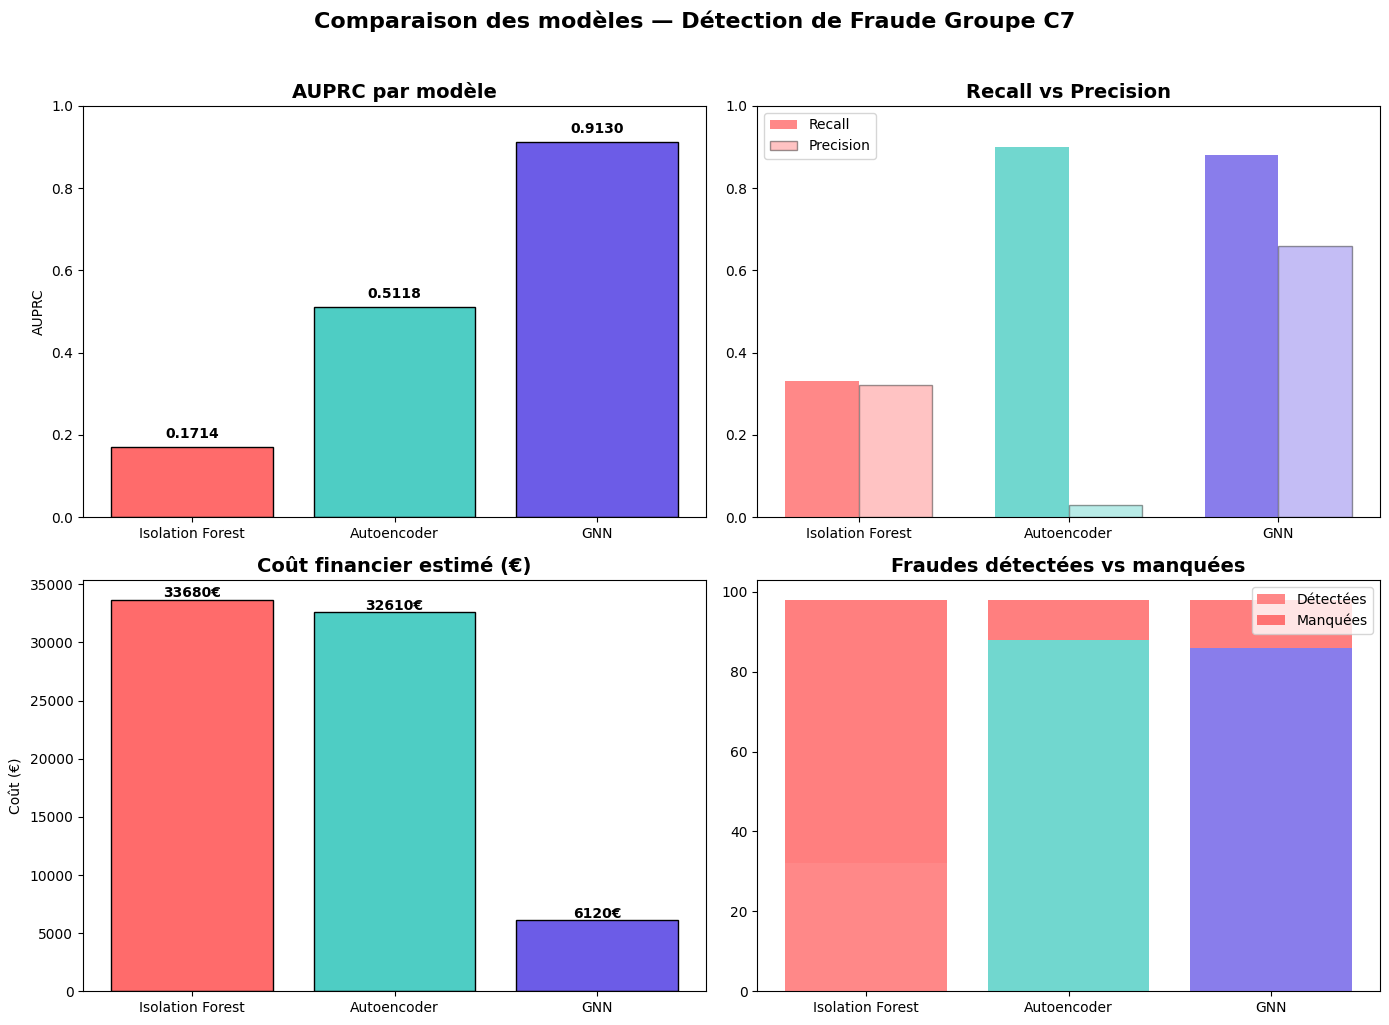

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

colors = ['#FF6B6B', '#4ECDC4', '#6C5CE7']
modeles = df_results['Modèle']

# Plot 1 — AUPRC
bars = axes[0,0].bar(modeles, df_results['AUPRC'], color=colors, edgecolor='black')
axes[0,0].set_title('AUPRC par modèle', fontsize=14, fontweight='bold')
axes[0,0].set_ylabel('AUPRC')
axes[0,0].set_ylim(0, 1)
for bar, val in zip(bars, df_results['AUPRC']):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                   f'{val:.4f}', ha='center', fontweight='bold')

# Plot 2 — Recall & Precision
x = np.arange(len(modeles))
width = 0.35
axes[0,1].bar(x - width/2, df_results['Recall Fraude'], width, 
              label='Recall', color=colors, alpha=0.8)
axes[0,1].bar(x + width/2, df_results['Precision Fraude'], width,
              label='Precision', color=colors, alpha=0.4, edgecolor='black')
axes[0,1].set_title('Recall vs Precision', fontsize=14, fontweight='bold')
axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels(modeles)
axes[0,1].legend()
axes[0,1].set_ylim(0, 1)

# Plot 3 — Coût financier
bars3 = axes[1,0].bar(modeles, df_results['Coût financier (€)'], 
                       color=colors, edgecolor='black')
axes[1,0].set_title('Coût financier estimé (€)', fontsize=14, fontweight='bold')
axes[1,0].set_ylabel('Coût (€)')
for bar, val in zip(bars3, df_results['Coût financier (€)']):
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                   f'{val}€', ha='center', fontweight='bold')

# Plot 4 — Fraudes détectées vs manquées
axes[1,1].bar(modeles, df_results['Fraudes détectées'], 
              label='Détectées', color=colors, alpha=0.8)
axes[1,1].bar(modeles, df_results['Faux Négatifs'],
              bottom=df_results['Fraudes détectées'],
              label='Manquées', color='red', alpha=0.5)
axes[1,1].set_title('Fraudes détectées vs manquées', fontsize=14, fontweight='bold')
axes[1,1].legend()

plt.suptitle('Comparaison des modèles — Détection de Fraude Groupe C7', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

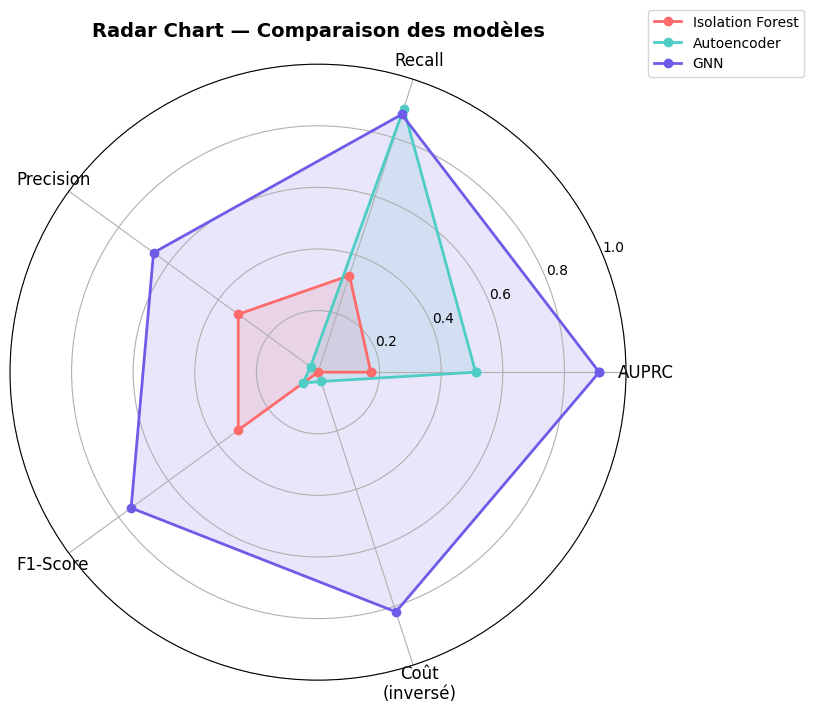

In [4]:
from matplotlib.patches import FancyArrowPatch

categories = ['AUPRC', 'Recall', 'Precision', 'F1-Score', 'Coût\n(inversé)']
N = len(categories)

# Normaliser le coût (inversé : moins c'est cher, mieux c'est)
max_cout = max(df_results['Coût financier (€)'])
cout_normalise = [1 - (c/max_cout) for c in df_results['Coût financier (€)']]

values = {
    'Isolation Forest': [0.1714, 0.33, 0.32, 0.32, cout_normalise[0]],
    'Autoencoder':      [0.5118, 0.90, 0.03, 0.06, cout_normalise[1]],
    'GNN':              [0.9130, 0.88, 0.66, 0.75, cout_normalise[2]]
}

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(1, 1, figsize=(8, 8), subplot_kw=dict(polar=True))

colors_radar = ['#FF6B6B', '#4ECDC4', '#6C5CE7']

for (model, vals), color in zip(values.items(), colors_radar):
    vals_plot = vals + vals[:1]
    ax.plot(angles, vals_plot, 'o-', linewidth=2, label=model, color=color)
    ax.fill(angles, vals_plot, alpha=0.15, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=12)
ax.set_ylim(0, 1)
ax.set_title('Radar Chart — Comparaison des modèles', 
             size=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

In [5]:
print("=" * 60)
print("   CONCLUSION — PROJET C.7 DÉTECTION DE FRAUDE")
print("   Groupe C7 | ECE Paris Ing4 Finance")
print("=" * 60)

print("""
🥇 MEILLEUR MODÈLE : GNN (Graph Neural Network)
   - AUPRC : 0.9130 (5x meilleur que l'Autoencoder)
   - F1-Score fraude : 0.75
   - Coût financier : 6120€ (5x moins cher)

📊 RÉSUMÉ DES APPROCHES :

   1. Isolation Forest (baseline non-supervisé)
      → Simple mais limité : AUPRC 0.17
      → Utile comme référence

   2. Autoencoder (deep learning non-supervisé)
      → Bon recall (90%) mais trop de faux positifs
      → AUPRC 0.51 : amélioration x3

   3. GNN (apprentissage sur graphe)
      → Exploite les RELATIONS entre transactions
      → Meilleur compromis precision/recall
      → AUPRC 0.91 : niveau production

🔄 PIPELINE TEMPS RÉEL :
   → Seuils adaptatifs selon le taux de fraude
   → Fenêtre glissante de 100 transactions
   → Coût minimal : 210€ sur 500 transactions

💡 APPORT DU SMOTE :
   → Rééquilibrage 577:1 → 2:1
   → Amélioration significative du recall
""")

   CONCLUSION — PROJET C.7 DÉTECTION DE FRAUDE
   Groupe C7 | ECE Paris Ing4 Finance

🥇 MEILLEUR MODÈLE : GNN (Graph Neural Network)
   - AUPRC : 0.9130 (5x meilleur que l'Autoencoder)
   - F1-Score fraude : 0.75
   - Coût financier : 6120€ (5x moins cher)

📊 RÉSUMÉ DES APPROCHES :

   1. Isolation Forest (baseline non-supervisé)
      → Simple mais limité : AUPRC 0.17
      → Utile comme référence

   2. Autoencoder (deep learning non-supervisé)
      → Bon recall (90%) mais trop de faux positifs
      → AUPRC 0.51 : amélioration x3

   3. GNN (apprentissage sur graphe)
      → Exploite les RELATIONS entre transactions
      → Meilleur compromis precision/recall
      → AUPRC 0.91 : niveau production

🔄 PIPELINE TEMPS RÉEL :
   → Seuils adaptatifs selon le taux de fraude
   → Fenêtre glissante de 100 transactions
   → Coût minimal : 210€ sur 500 transactions

💡 APPORT DU SMOTE :
   → Rééquilibrage 577:1 → 2:1
   → Amélioration significative du recall

